In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import datetime as dt
import os

plt.style.use('seaborn-v0_8-whitegrid')

os.makedirs("project7-montecarlo_riskforecasting_charts", exist_ok=True)


end_date = dt.date.today()
start_date = end_date - dt.timedelta(days = 5*365)

stocks = ["AAPL", "KO", "^GSPC", "NVDA", "GC=F", "MSFT"]

df = yf.download(stocks, start= start_date, end = end_date)['Close']

df.head(10) 

[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,GC=F,KO,MSFT,NVDA,^GSPC
Date,,,,,,
2021-08-27,144.940125,1816.599976,47.998581,287.649475,22.557970,4509.370117
2021-08-30,149.348801,1809.000000,48.455708,291.363586,22.609797,4528.790039
2021-08-31,148.090591,1815.000000,48.567833,289.722412,22.311771,4522.680176
2021-09-01,148.753860,1813.099976,48.895596,289.674500,22.367590,4524.089844
2021-09-02,149.865768,1808.699951,48.964596,289.021912,22.322739,4536.950195
2021-09-03,150.499786,1830.900024,48.930088,289.012207,22.768276,4535.430176
2021-09-07,152.830917,1795.900024,48.015831,288.090973,22.587864,4520.029785
2021-09-08,151.289825,1790.699951,48.662720,288.119720,22.265924,4514.069824
2021-09-09,150.275467,1797.400024,48.179710,285.278931,22.104452,4493.279785


In [126]:
returns = df.pct_change().dropna()
returns.head(10)

C:\Users\yashr\AppData\Local\Temp\ipykernel_9504\1362317409.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = df.pct_change().dropna()


Ticker,AAPL,GC=F,KO,MSFT,NVDA,^GSPC
Date,,,,,,
2021-08-30,0.030417,-0.004184,0.009524,0.012912,0.002297,0.004307
2021-08-31,-0.008425,0.003317,0.002314,-0.005633,-0.013181,-0.001349
2021-09-01,0.004479,-0.001047,0.006749,-0.000165,0.002502,0.000312
2021-09-02,0.007475,-0.002427,0.001411,-0.002253,-0.002005,0.002843
2021-09-03,0.004231,0.012274,-0.000705,-0.000034,0.019959,-0.000335
2021-09-07,0.015489,-0.019116,-0.018685,-0.003188,-0.007924,-0.003396
2021-09-08,-0.010084,-0.002896,0.013472,0.000100,-0.014253,-0.001319
2021-09-09,-0.006705,0.003742,-0.009926,-0.009860,-0.007252,-0.004606
2021-09-10,-0.033102,-0.004340,-0.004476,-0.005181,0.013573,-0.007723


In [127]:
volatility = returns.std()
volatility

Ticker
AAPL     0.017668
GC=F     0.011828
KO       0.010499
MSFT     0.017722
NVDA     0.032640
^GSPC    0.010728
dtype: float64

In [128]:
initialwealth = 1
tradingdays = 5*252
num_sims = 10000
dt = 1
np.random.seed(42)

In [129]:
shocks = np.random.normal(loc=0, scale=1, size = (tradingdays, num_sims))
shocks.shape

(1260, 10000)

In [130]:
shocks[:5, :5]

array([[ 0.49671415, -0.1382643 ,  0.64768854,  1.52302986, -0.23415337],
       [-0.67849473, -0.30549946, -0.59738106,  0.11041805,  1.19717853],
       [ 0.34828625,  0.28332359, -0.93651985,  0.57958422, -1.49008268],
       [-1.98057197, -1.05498565, -0.58702841,  0.14966891,  1.02416233],
       [-0.47185755,  1.01270247, -0.19818685,  0.09056926,  0.71739061]])

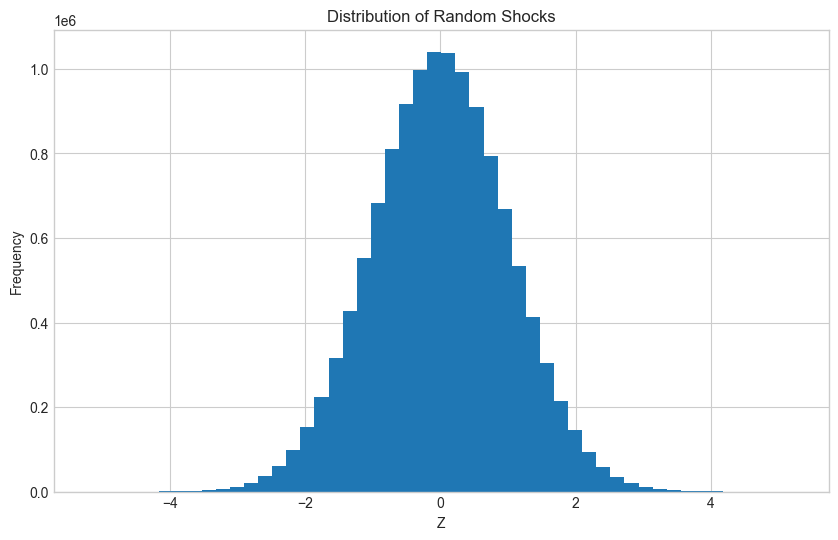

In [131]:
plt.figure(figsize=(10, 6))

plt.hist(shocks.flatten(), bins=50)

plt.title("Distribution of Random Shocks")
plt.xlabel("Z")
plt.ylabel("Frequency")

plt.show()

In [132]:
def geometric_brownian_motion(price, mu, sigma, dt, Z):
    growth_factor = np.exp(
        (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    )

    newprice = price*growth_factor
    return newprice


In [133]:
optimizedreturns = pd.read_csv("optimized_returns.csv")
optimizedreturns = optimizedreturns.squeeze()
optimizedreturns

0       0.015738
1      -0.003570
2       0.000341
3      -0.004139
4       0.011772
          ...   
1249    0.008938
1250    0.000752
1251    0.002472
1252    0.000049
1253   -0.001668
Name: 0, Length: 1254, dtype: float64

In [134]:
wealthmatrix = np.ones(shape = (tradingdays, num_sims))

mu = optimizedreturns.mean()
sigma = optimizedreturns.std()

for i in range(1, tradingdays):
    wealthmatrix[i,:] = geometric_brownian_motion(
        wealthmatrix[i-1,:], mu, sigma, dt, shocks[i-1,:])

wealthmatrix.shape

(1260, 10000)

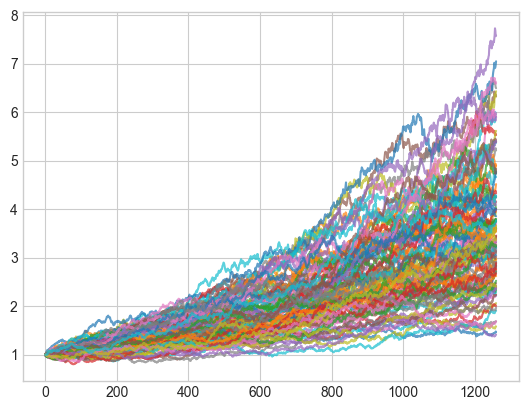

In [135]:
plt.plot(wealthmatrix[:,:100], alpha = 0.7)

In [136]:
print(wealthmatrix[-1, :].mean())
print(wealthmatrix[-1, :].std())
print(wealthmatrix[-1, :].min())
print(wealthmatrix[-1, :].max())

3.6426767642463274
1.2842016396956863
0.8167045009296745
10.883442041309557


In [137]:
terminalwealth = wealthmatrix[-1, :]
percentile_5 = np.percentile(terminalwealth, 5)
percentile_25 = np.percentile(terminalwealth, 25)
percentile_50 = np.median(terminalwealth)
percentile_75 = np.percentile(terminalwealth, 75)
percentile_95 = np.percentile(terminalwealth, 95)

print(percentile_5)
print(percentile_25)
print(percentile_50)
print(percentile_75)
print(percentile_95)

1.9540078272071504
2.7318246558184285
3.431230291845492
4.3437826796987995
5.997501401584812


In [138]:
(terminalwealth < 1).sum() / num_sims

np.float64(0.0004)

In [139]:
print((terminalwealth > 2).sum() / num_sims)
print((terminalwealth > 5).sum() / num_sims)
index500 = (1 + returns['^GSPC']).cumprod().iloc[-1]
print((terminalwealth > index500).sum() / num_sims)

0.9417
0.1343
0.9783


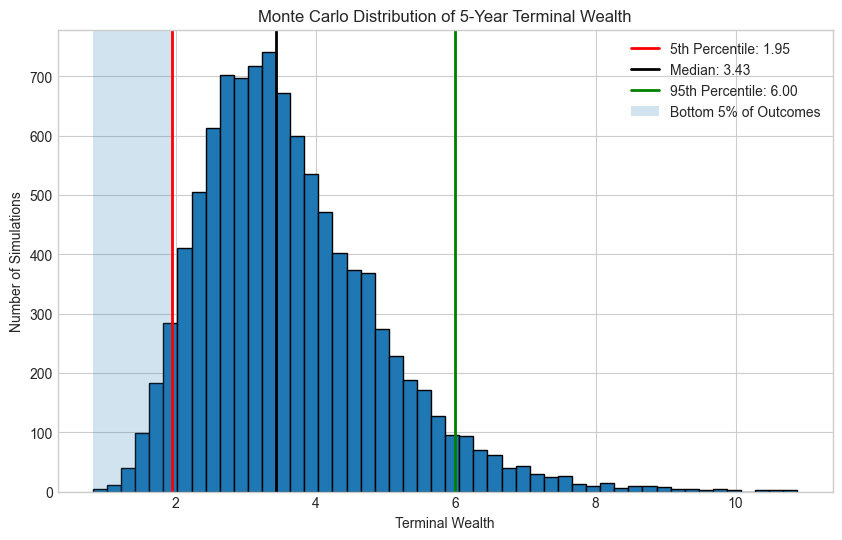

In [140]:
plt.figure(figsize=(10, 6))

plt.hist(terminalwealth, bins=50, edgecolor="black"
)

plt.xlabel("Terminal Wealth")
plt.ylabel("Number of Simulations")
plt.title("Monte Carlo Distribution of 5-Year Terminal Wealth")

plt.axvline(
    x=percentile_5,
    color="red",
    linewidth=2,
    label=f"5th Percentile: {percentile_5:.2f}"
)

plt.axvline(
    x=percentile_50,
    color="black",
    linewidth=2,
    label=f"Median: {percentile_50:.2f}"
)

plt.axvline(
    x=percentile_95,
    color="green",
    linewidth=2,
    label=f"95th Percentile: {percentile_95:.2f}"
)

plt.axvspan(
    terminalwealth.min(),
    percentile_5,
    alpha=0.2,
    label="Bottom 5% of Outcomes"
)

plt.legend()

plt.savefig(
    "project7-montecarlo_riskforecasting_charts/terminalwealthdistribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [141]:
terminalreturns = terminalwealth - 1
var90_threshold = np.percentile(terminalreturns, 10)
var95_threshold = np.percentile(terminalreturns, 5)
var99_threshold = np.percentile(terminalreturns, 1)

var90 = -var90_threshold
var95 = -var95_threshold
var99 = -var99_threshold

cvar90 = -terminalreturns[terminalreturns <= var90_threshold].mean()
cvar95 = -terminalreturns[terminalreturns <= var95_threshold].mean()
cvar99 = -terminalreturns[terminalreturns <= var99_threshold].mean()

In [142]:
investmentamount = 1000

var90dollars = investmentamount*var90
var95dollars = investmentamount*var95
var99dollars = investmentamount*var99

cvar90dollars = investmentamount*cvar90
cvar95dollars = investmentamount*cvar95
cvar99dollars = investmentamount*cvar99

In [143]:
fifthpercentiles = []
medianpercentiles = []
ninetyfifthpercentiles = []

for i in range(tradingdays):
    fifthpercentile = np.percentile(wealthmatrix[i,:], 5)
    medianpercentile = np.median(wealthmatrix[i,:])
    ninetyfifthpercentile =  np.percentile(wealthmatrix[i,:], 95)

    fifthpercentiles.append(fifthpercentile)
    medianpercentiles.append(medianpercentile)
    ninetyfifthpercentiles.append(ninetyfifthpercentile)

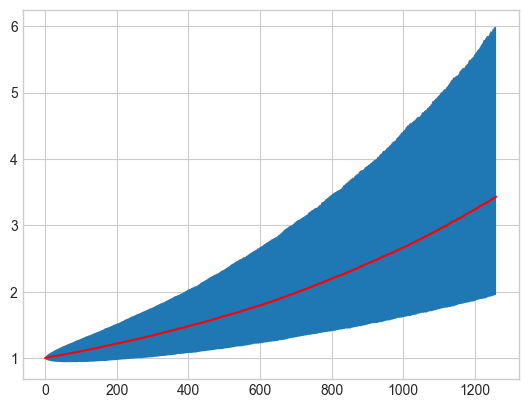

In [144]:
plt.plot(medianpercentiles, color = 'red')

plt.fill_between(np.arange(tradingdays), fifthpercentiles, ninetyfifthpercentiles)

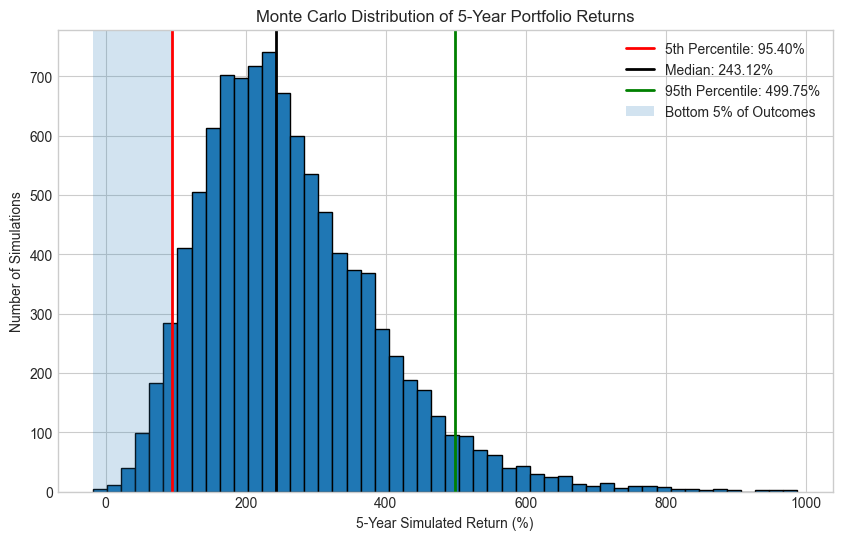

In [ ]:
plt.figure(figsize=(10, 6))

returnspercentile_5 = np.percentile(terminalreturns, 5)*100
medianreturns = np.median(terminalreturns)*100
returnspercentile_95 = np.percentile(terminalreturns, 95)*100

plt.hist(
    terminalreturns * 100,
    bins=50,
    edgecolor="black"
)

plt.xlabel("5-Year Simulated Return (%)")
plt.ylabel("Number of Simulations")
plt.title("Monte Carlo Distribution of 5-Year Portfolio Returns")

plt.axvline(
    x=percentile_5 * 0 + (np.percentile(terminalreturns, 5) * 100),
    color="red",
    linewidth=2,
    label=f"5th Percentile: {returnspercentile_5:.2f}%"
)

plt.axvline(
    x=np.median(terminalreturns) * 100,
    color="black",
    linewidth=2,
    label=f"Median: {medianreturns:.2f}%"
)

plt.axvline(
    x=np.percentile(terminalreturns, 95) * 100,
    color="green",
    linewidth=2,
    label=f"95th Percentile: {returnspercentile_95:.2f}%"
)

plt.axvspan(
    terminalreturns.min() * 100,
    np.percentile(terminalreturns, 5) * 100,
    alpha=0.2,
    label= "Bottom 5% of Outcomes"
)

plt.legend()

plt.savefig(
    "project7-montecarlo_riskforecasting_charts/terminalreturnsdistribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [146]:
loss_probability = (terminalreturns < 0).mean()

print(loss_probability)
print(loss_probability * 100)
print((terminalreturns < 0).sum())

0.0004
0.04
4


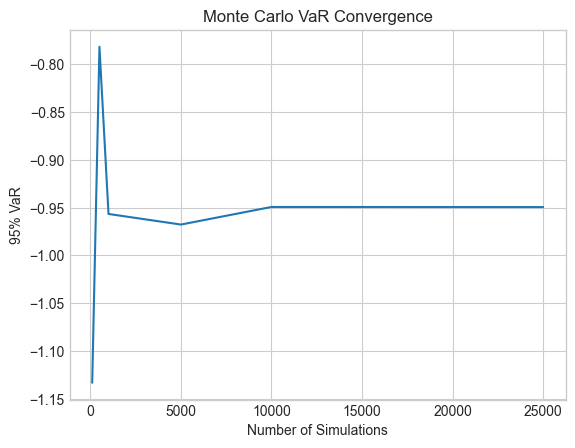

In [147]:
simulation_counts = [100, 500, 1000, 5000, 10000, 25000]
np.random.seed(42)

results = pd.DataFrame(
    index=["Mean Terminal Wealth", "5th Percentile", "95th Percentile", "95% VaR"])

for num_sims in simulation_counts:
    shocks = np.random.normal(loc=0, scale=1, size=(tradingdays, num_sims))

    wealthmatrix = np.ones((tradingdays, num_sims))

    for i in range(1, tradingdays):
        wealthmatrix[i, :] = geometric_brownian_motion(wealthmatrix[i-1, :], mu, sigma, dt, shocks[i-1, :])

    terminalwealth = wealthmatrix[-1, :]
    terminalreturns = terminalwealth - 1

    results[f"{num_sims} Sims"] = [
        terminalwealth.mean(),
        np.percentile(terminalwealth, 5),
        np.percentile(terminalwealth, 95),
        -np.percentile(terminalreturns, 5)
    ]

plt.xlabel("Number of Simulations")
plt.ylabel("95% VaR")
plt.title("Monte Carlo VaR Convergence")

plt.plot(simulation_counts, results.loc["95% VaR"])

plt.savefig("project7-montecarlo_riskforecasting_charts/montecarloconvergence.png")
